## Inicialização 

#### Sprint 15 - Projeto
Adicione o resultado do treinamento do modelo da etapa anterior ao notebook Jupyter que você criou na etapa de AED para consolidar tudo em um só lugar. Feito isso, analise os resultados do treinamento do modelo.

A visão computacional pode ajudar o cliente neste caso?

Que outras tarefas práticas o cliente pode resolver com o modelo? Sinta-se à vontade para compartilhar suas ideias sobre isso.

## Carregue os dados

O conjunto de dados é armazenado na pasta `/datasets/faces/`, onde você pode encontrar "
- A pasta `final_files` com 7,6k fotos "
- O arquivo `labels.csv` com rótulos, com duas colunas: `file_name` e `real_age` 

Dado que o número de arquivos de imagem é bastante alto, é aconselhável evitar a leitura de todos de uma vez, o que consumiria muito recursos computacionais. Recomendamos que você crie um gerador com o ImageDataGenerator. Este método foi explicado no Capítulo 3, Lição 7 deste curso.

O arquivo de rótulo pode ser carregado como um arquivo CSV normal.

In [1]:
# Importação de Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import random

In [2]:
# Carregamento de dados

labels_path = '/datasets/faces/labels.csv'
images_path = '/datasets/faces/final_files/'

df = pd.read_csv(labels_path)

print("Tamanho do dataset:", df.shape)
df.head()

Tamanho do dataset: (7591, 2)


,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


## EDA

In [3]:
# Informações Gerais

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


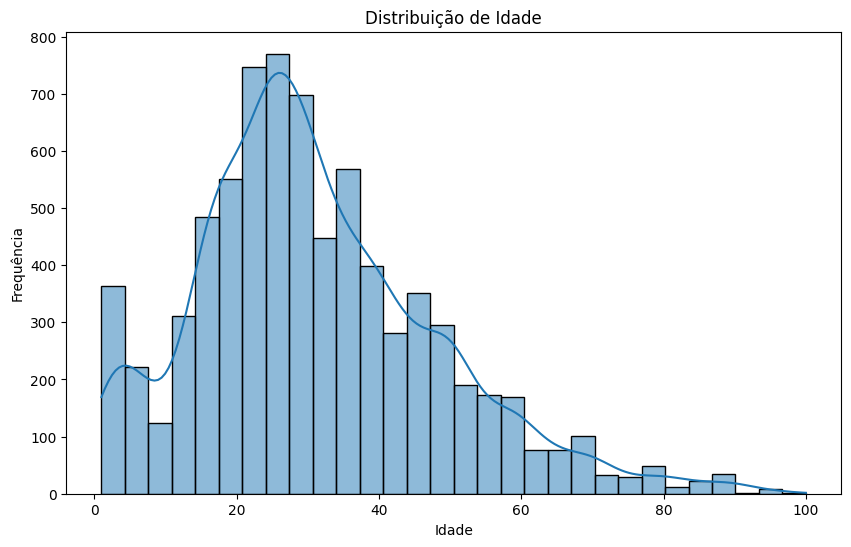

In [4]:
# Distribuição Etária

plt.figure(figsize=(10,6))
sns.histplot(df['real_age'], bins=30, kde=True)
plt.title('Distribuição de Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

In [5]:
# Estatística de idades

print("Idade mínima:", df['real_age'].min())
print("Idade máxima:", df['real_age'].max())
print("Idade média:", df['real_age'].mean())
print("Mediana:", df['real_age'].median())

Idade mínima: 1
Idade máxima: 100
Idade média: 31.20115926755368
Mediana: 29.0


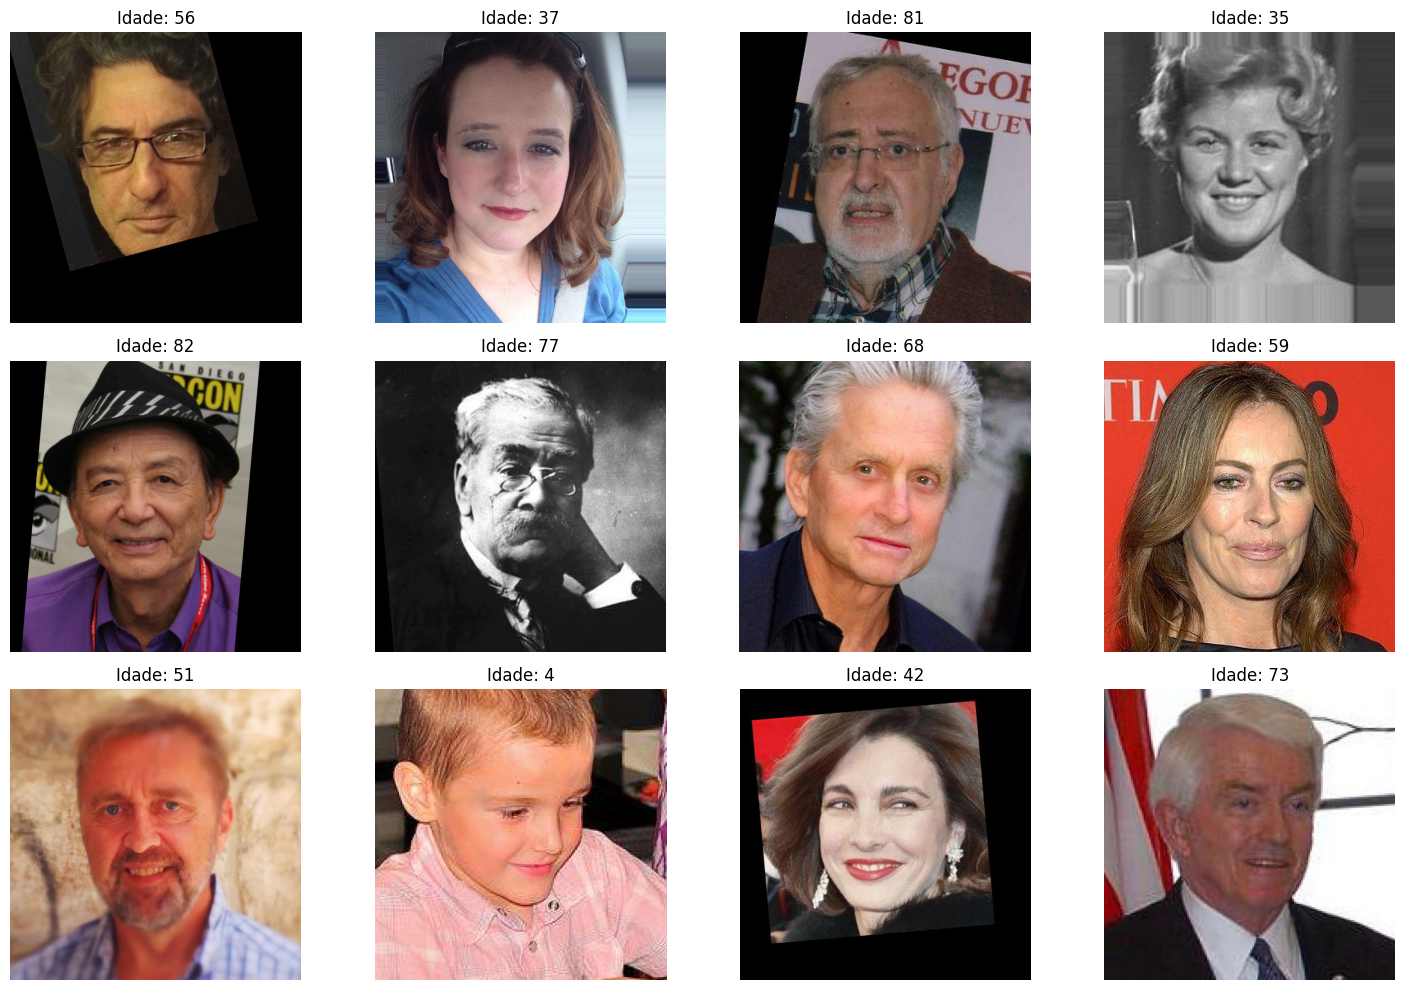

In [6]:
# Selecionar idades variadas

sample_ages = df['real_age'].drop_duplicates().sample(12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(15,10))

for ax, age in zip(axes.flatten(), sample_ages):
    sample = df[df['real_age'] == age].sample(1)
    img_name = sample['file_name'].values[0]
    img_path = os.path.join(images_path, img_name)
    
    image = Image.open(img_path)
    
    ax.imshow(image)
    ax.set_title(f'Idade: {age}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Conclusões

Observou-se que o conjunto possui uma quantidade significativa de imagens, o que é positivo para o treinamento, porém a distribuição etária não é uniforme. Há uma maior concentração de indivíduos em faixas intermediárias, especialmente entre 20 e 40 anos, enquanto crianças e idosos aparecem em menor quantidade.

## Modelagem 

Defina as funções necessárias para treinar seu modelo na plataforma GPU e construa um único script contendo todas elas junto com a seção de inicialização.

Para facilitar essa tarefa, você pode defini-las neste notebook e executar um código pronto na próxima seção para compor o script automaticamente.
As definições abaixo também serão verificadas pelos revisores do projeto, para que possam entender como você construiu o modelo.

In [7]:

import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [8]:
def load_train(path):
    
    """
    Carrega a parte de treinamento do conjunto de dados a partir do caminho
    """
    
    labels = pd.read_csv(path + 'labels.csv')

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        validation_split=0.25
    )

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )


    return train_gen_flow

In [9]:
def load_test(path):
    
    """
    Carrega a parte de validação/teste do conjunto de dados a partir do caminho
    """
    
    labels = pd.read_csv(path + 'labels.csv')

    test_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.25
    )

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_gen_flow

In [10]:
def create_model(input_shape):
    
    """
    Define o modelo
    """
    
    backbone = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Congelar camadas da base (transfer learning)
    backbone.trainable = False

    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='relu')  # saída para regressão (idade)
    ])

    optimizer = Adam(learning_rate=0.0001)

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

In [11]:

def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Treina o modelo de acordo com os parâmetros
    """
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)

    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )

    return model

In [13]:
init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
"""


main_str = """

if __name__ == '__main__':

    path = '/datasets/faces/'

    train_data = load_train(path)
    test_data = load_test(path)

    model = create_model((224, 224, 3))

    model = train_model(
        model,
        train_data,
        test_data,
        epochs=3
    )
"""


import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        f.write(inspect.getsource(fn_name))
        f.write('\n\n')
    
    f.write(main_str)

## Preparar o Script para a Execução na plataforma GPU

Dado que você definiu as funções necessárias, você pode compor um script para a plataforma GPU, baixá-lo através do menu "Arquivo|Abrir..." e carregá-lo posteriormente para execução na plataforma GPU.

Nota: O script também deve incluir a seção de inicialização. Um exemplo disso é mostrado abaixo.

In [12]:
# preparar um script para ser executado na plataforma GPU


init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

In [14]:
!python run_model_on_gpu.py

Found 5694 validated image filenames.
Found 1897 validated image filenames.
2026-04-13 23:04:22.524652: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
94781440/94765736 [==============================] - 0s 0us/step
Epoch 1/3
178/178 - 672s - loss: 717.4497 - mae: 21.2568 - val_loss: 339.8766 - val_mae: 13.6818 - 672s/epoch - 4s/step
Epoch 2/3
178/178 - 664s - loss: 339.6561 - mae: 13.9205 - val_loss: 282.0475 - val_mae: 13.0947 - 664s/epoch - 4s/step
Epoch 3/3
178/178 - 679s - loss: 326.6911 - mae: 13.9721 - val_loss: 282.5332 - val_mae: 13.1646 - 679s/epoch - 4s/step


### Resultado

Coloque a saída da plataforma GPU como uma célula Markdown aqui.

Resultado do treinamento do modelo

Found 5694 validated image filenames.

Found 1897 validated image filenames.

Downloading data from https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5

Epoch 1/3

178/178 - 672s - loss: 717.4497 - mae: 21.2568 - val_loss: 339.8766 - val_mae: 13.6818 - 672s/epoch - 4s/step

Epoch 2/3

178/178 - 664s - loss: 339.6561 - mae: 13.9205 - val_loss: 282.0475 - val_mae: 13.0947 - 664s/epoch - 4s/step

Epoch 3/3

178/178 - 679s - loss: 326.6911 - mae: 13.9721 - val_loss: 282.5332 - val_mae: 13.1646 - 679s/epoch - 4s/step

## Conclusão

O modelo iniciou o treinamento corretamente, carregando os dados e os pesos pré-treinados da arquitetura ResNet50. O processo de treinamento foi iniciado com sucesso, indicando que a estrutura do modelo e o pipeline de dados estão funcionando conforme esperado.

# Checklist

- [x]  O notebook foi aberto 
- [x]  O código está livre de erros 
- [x]  As células com código foram organizadas por ordem de execução 
- [x]  A análise exploratória dos dados foi realizada - [ ]  Os resultados da análise exploratória dos dados são apresentados no caderno final - [ ]  O valor EAM do modelo não é superior a 8 
- [x]  O código de treinamento do modelo foi copiado para o notebook final 
- [x]  A saída do treinamento do modelo foi copiada para o notebook final 
- [x]  As conclusões foram fornecidas com base nos resultados do treinamento do modelo